In [1]:
import os
import time
import csv
import json
import tifffile
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la
from scipy import interpolate, signal
from scipy.optimize import least_squares
import pandas as pd
import seaborn as sns
import subprocess
#from osgeo import gdal, osr, gdalconst, gdal_array

In [2]:
# read radiometric file (csv)
def read_bfile(file):
    # ファイルのベース名に“_B.csv”を追加して新しいファイル名を作成
    fileb = os.path.splitext(file)[0] + "_B.csv"
    # CSVファイルをpandasを使って読み込む
    df = pd.read_csv(fileb)
    # パラメータ配列を初期化
    param = np.zeros((185, 5), dtype=float)
    # DataFrameからデータを抽出し、param配列に格納
    for i in range(min(185, len(df))):  # レコード数が185を超えないようにする
        for j in range(5):
            param[i, j] = float(df.iloc[i, j + 1])
    #‘CenterWavelengthNanometer’, ‘FullWidthAtHalfMaximumNanometer’,
    #‘SolarIrradianceWatt/Meter2/Micron’, ‘ReflectanceMulti’, ‘ReflectanceAdd’
    return param

# read meta data (txt)
def read_tfile(file):
    fileb = os.path.splitext(file)[0]  # ファイルの拡張子を削除し、ベース名を取得
    fileb = fileb + ".txt"  # ベース名に“.txt”を追加して、新しいファイル名を作成
    csv_file = open(fileb, "r")  # txtファイルを読み取りモードで開く
    record_list = []  # レコードを格納するリストを初期化
    record = csv_file.readline()  # 2行目から読み込みを開始
    while record :  # ファイルの終わりまでループ
        record_list.append(record.rstrip().split("="))  # 各行を読み込み、改行文字を取り除き‘=’で分割してリストにし、record_listに追加
        record = csv_file.readline()  # 次の行を読み込む
    for record in record_list:  # 全レコードをループ
        if(record[0]=="RadianceMultiVNIR                                                      "):
            radiancemultivnir = float(record[1])
        if(record[0]=="RadianceAddVNIR                                                        "):
            radianceaddvnir = float(record[1])
        if(record[0]=="RadianceMultiSWIR                                                      "):
            radiancemultiswir = float(record[1])
        if(record[0]=="RadianceAddSWIR                                                        "):
            radianceaddswir = float(record[1])
    return radiancemultivnir, radiancemultiswir, radianceaddvnir, radianceaddswir

# 入力画像に放射補正を適用
def apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir):
    im = np.ones([img.shape[0], img.shape[1]])  # 画像の高さと幅に基づいて、全ての要素が1のマスクを作成
    # no data area
    im[img[:,:,10] == 0] = 0  # 画像のバンド10が0の位置に対して、マスクを0に設定（データがない領域を示す）
    # change to float
    img = 1.0 * img  # 入力画像を浮動小数点数型に変換
    # apply radiometric vnir
    for j in range(58):  # 0から57バンド（VNIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultivnir + radaddvnir  # 各バンドの値にradmultivnirを掛けてradaddvnirを加える
    # apply radiometric swir
    for j in range(58, 185):  # 58から184バンド（SWIR領域）に対して、放射補正を適用
        img[:,:,j] = img[:,:,j] * radmultiswir + radaddswir  # 各バンドの値にradmultiswirを掛けてradaddswirを加える
    img[im == 0] = 0  # マスクが0の位置（データがない領域）に対して、画像の値を0に設定
    return img

# ピクセル空間から地理空間への変換
def show_xy(src, x, y):
    width = src.RasterXSize # srcラスターデータセットの横幅（列数）を取得し格納
    height = src.RasterYSize # srcラスターデータセットの縦幅（行数）を取得し格納
    gt = src.GetGeoTransform() # srcラスターデータセットのジオトランスフォーム（地理変換情報）を取得し、gtに格納
    # gtは6つの要素を持つタプルで、地理座標への変換情報を含む
    # gt[0]: 左上隅のX座標（地理座標系の原点のX座標）。
    # gt[1]: 水平方向のピクセル解像度（ピクセルサイズ、X方向のスケール）。
    # gt[2]: 水平方向の回転（通常は0）。
    # gt[3]: 左上隅のY座標（地理座標系の原点のY座標）。
    # gt[4]: 垂直方向の回転（通常は0）。
    # gt[5]: 垂直方向のピクセル解像度（ピクセルサイズ、Y方向のスケール。通常は負の値、地図の上が北である場合）。
    minx = gt[0]
    miny = gt[3] + width * gt[4] + height * gt[5]
    maxx = gt[0] + width * gt[1] + height * gt[2]
    maxy = gt[3]
    X = gt[0] + x * gt[1] + y * gt[2]
    Y = gt[3] + x * gt[4] + y * gt[5]
    return X, Y

# 地理空間から緯度経度(WGS84)に変換
#def show_latlon(src, x, y):
    old_cs= osr.SpatialReference() # 元の座標系を入れるオブジェクト
    old_cs.ImportFromWkt(src.GetProjectionRef()) # データセットから取得した投影情報（WKT形式）
    # WGS84座標系のWKT（Well-Known Text）表現を文字列として定義
    wgs84_wkt = """
        GEOGCS["WGS 84",
            DATUM["WGS_1984",
                SPHEROID["WGS 84",6378137,298.257223563,
                    AUTHORITY["EPSG","7030"]],
                AUTHORITY["EPSG","6326"]],
            PRIMEM["Greenwich",0,
                AUTHORITY["EPSG","8901"]],
            UNIT["degree",0.01745329251994328,
                AUTHORITY["EPSG","9122"]],
            AUTHORITY["EPSG","4326"]]"""
    new_cs = osr.SpatialReference() # 新しい座標系を入れるオブジェクト
    new_cs .ImportFromWkt(wgs84_wkt) # 定義したWGS84のWKT文字列をインポート
    # old_csからnew_csへの座標変換を行うためのosr.CoordinateTransformationオブジェクトを作成し、transformに格納
    transform = osr.CoordinateTransformation(old_cs,new_cs)
    X, Y = show_xy(src, x, y) #ピクセル空間から地理空間への変換
    # 計算した地理座標XとYを、transformを使ってWGS84座標系（緯度経度）に変換、格納します
    latlong = transform.TransformPoint(X, Y)
    return latlong

# ハイパースペクトル画像から特定のバンドを取り出して表示するための関数
def get_rgb(img, b=8, g=18, r=28):
    ims = np.zeros([img.shape[0], img.shape[1], 3])  # 画像の高さ、幅、およびRGBの3チャンネルを持つゼロ配列を作成
    ims[:,:,0] = img[:,:,r]    #R
    ims[:,:,1] = img[:,:,g]    #G
    ims[:,:,2] = img[:,:,b]    #B
    max = np.max(ims)/3  # 画像配列の最大値を取得
    ims /= max   # 画像を max で割って正規化
    ims = np.clip(ims, 0.0, 1.0)  # 画像配列の値を0から255の範囲にクランプ
    #RGBの強さは小数点の場合0から1, 整数の場合は0から255の範囲にある必要がある。
    return ims
    
def show_img(img):
    fig, ax = plt.subplots()  # fig と ax を定義
    im = ax.imshow(img)  # 画像を表示
    plt.show()
    
#SWIRのデータを抽出
def get_radiance(img, param, y, x):
    wave = param[58:185,0]
    rad = img[y, x, 58:185]
    list_data = [wave, rad]
    list_data_T = np.array(list_data).T
    return list_data_T

In [2]:
data1 = pd.read_csv(r"E:\新しいフォルダー\MODTRAN\normal\5p5059.csv")
display(data1)
data1=np.array(data1).T
data1 [1:,:] = data1[1:,:] * 100
print(data1)
display(data1)

,Waveln,380,400,420,440,460,480,500
0,380.0,5.422950,5.423040,5.423150,5.423190,5.423290,5.423390,5.423460
1,381.0,6.370990,6.371070,6.371190,6.371230,6.371370,6.371500,6.371580
2,382.0,5.211070,5.211120,5.211220,5.211330,5.211380,5.211460,5.211570
3,383.0,4.278450,4.278540,4.278600,4.278650,4.278730,4.278780,4.278830
4,384.0,4.000290,4.000360,4.000390,4.000450,4.000500,4.000560,4.000630
...,...,...,...,...,...,...,...,...
2116,2496.0,0.000276,0.000276,0.000276,0.000276,0.000276,0.000276,0.000276
2117,2497.0,0.000289,0.000289,0.000289,0.000289,0.000289,0.000289,0.000289
2118,2498.0,0.000327,0.000327,0.000327,0.000327,0.000327,0.000327,0.000327
2119,2499.0,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400,0.000400


[[3.80000e+02 3.81000e+02 3.82000e+02 ... 2.49800e+03 2.49900e+03
  2.50000e+03]
 [5.42295e+02 6.37099e+02 5.21107e+02 ... 3.26572e-02 3.99838e-02
  3.63924e-02]
 [5.42304e+02 6.37107e+02 5.21112e+02 ... 3.26570e-02 3.99833e-02
  3.63923e-02]
 ...
 [5.42329e+02 6.37137e+02 5.21138e+02 ... 3.26562e-02 3.99819e-02
  3.63915e-02]
 [5.42339e+02 6.37150e+02 5.21146e+02 ... 3.26559e-02 3.99814e-02
  3.63913e-02]
 [5.42346e+02 6.37158e+02 5.21157e+02 ... 3.26556e-02 3.99809e-02
  3.63911e-02]]


array([[3.80000e+02, 3.81000e+02, 3.82000e+02, ..., 2.49800e+03,
        2.49900e+03, 2.50000e+03],
       [5.42295e+02, 6.37099e+02, 5.21107e+02, ..., 3.26572e-02,
        3.99838e-02, 3.63924e-02],
       [5.42304e+02, 6.37107e+02, 5.21112e+02, ..., 3.26570e-02,
        3.99833e-02, 3.63923e-02],
       ...,
       [5.42329e+02, 6.37137e+02, 5.21138e+02, ..., 3.26562e-02,
        3.99819e-02, 3.63915e-02],
       [5.42339e+02, 6.37150e+02, 5.21146e+02, ..., 3.26559e-02,
        3.99814e-02, 3.63913e-02],
       [5.42346e+02, 6.37158e+02, 5.21157e+02, ..., 3.26556e-02,
        3.99809e-02, 3.63911e-02]], shape=(8, 2121))

In [34]:
HISUI_IDX_START = 143     # range()の開始（含む）
HISUI_IDX_STOP  = 155    # range()の終了（含まない）
PARAM_IDX_START = 1570   # スライス開始（含む）
PARAM_IDX_STOP  = 1722   # スライス終了（含まない）
WAVE_WIDTH      = 1.0    # wavelength_adjustment_ch4 の刻み幅仮定

def instrumental_function(data, sigma, mu):
    column, row = data.shape
    x = data[0, :]
    out = np.zeros((column, row))
    out[0, :] = x
    center = np.mean(x) + mu
    gauss = np.exp(-(x - center)**2 / (2 * sigma**2))
    gauss /= gauss.sum()  
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode="same")
    return out


def extractdata(data):  # 範囲の選択（インデックス指定）
    return data[:, PARAM_IDX_START:PARAM_IDX_STOP]

def reflectance_correction(data, a, b, k):  # 反射率の考慮, 一次近似
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def estimated_by_ch4(data, c, start=380, step=20):
    """
    data[0, :] = wavelength (nm)
    data[1:, :] = spectra for each CH4 level (start, start+step, ...)
    """
    data = np.asarray(data)
    ch4 = start + step * np.arange(data.shape[0] - 1)  # 行1..末尾に対応
    pos = np.searchsorted(ch4, c)

    out = []
    for i in range(data.shape[1]):  # 各波長列
        if pos <= 0:
            val = data[1, i]                 # 最小条件にクリップ
        elif pos >= ch4.size:
            val = data[-1, i]                # 最大条件にクリップ
        else:
            lo, hi = pos - 1, pos
            t = (c - ch4[lo]) / (ch4[hi] - ch4[lo])
            val = (1 - t) * data[lo + 1, i] + t * data[hi + 1, i]  # +1 に注意
        out.append(val)
    return np.array(out)


def wavelength_adjustment_ch4(data_ch4, array, data_hisui,
                              hisui_start=HISUI_IDX_START,
                              hisui_stop=HISUI_IDX_STOP):
    w_hisui = data_hisui.iloc[hisui_start:hisui_stop, 0].to_numpy()
    out = np.empty_like(w_hisui, dtype=float)
    for i, w in enumerate(w_hisui):
        pos = np.searchsorted(array, w)
        if pos == 0:
            out[i] = data_ch4[0]
        elif pos >= len(array):
            out[i] = data_ch4[-1]
        else:
            x0, x1 = array[pos-1], array[pos]
            t = (w - x0) / (x1 - x0)            # ← 真の分割比
            out[i] = (1 - t) * data_ch4[pos-1] + t * data_ch4[pos]
    return out

def func_ch4(data, data_hisui, sigma, mu, a, b, c, k):
    out = instrumental_function(data, sigma, mu)
    out = extractdata(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_ch4(out, c)
    out = wavelength_adjustment_ch4(out, data[0, PARAM_IDX_START:PARAM_IDX_STOP], data_hisui)
    return out

def residuals_ch4(param, data, data_hisui):
    sigma, mu, a, b, c, k = param
    w_est = func_ch4(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[HISUI_IDX_START:HISUI_IDX_STOP, 1] - w_est

def estimate_param_ch4(data, data_hisui):  # b の推定
    max_ref = max(data_hisui.iloc[HISUI_IDX_START:HISUI_IDX_STOP, 1])
    rel_max_index = np.argmax(data_hisui.iloc[HISUI_IDX_START:HISUI_IDX_STOP, 1])
    abs_max_index = data_hisui.iloc[HISUI_IDX_START:HISUI_IDX_STOP].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]

    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extractdata(out)
    out = estimated_by_ch4(out, c=440)
    out = wavelength_adjustment_ch4(out, data[0, PARAM_IDX_START:PARAM_IDX_STOP], data_hisui)

    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b


In [14]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import least_squares

# --- 入力: CH4.csv と 観測スペクトル(obs_wl[nm], obs_I) ---
df = pd.read_csv("CH4.csv")
wl = df["wavelength"].values
mr = np.array([float(c) for c in df.columns if c != "wavelength"])
mr_cols = [c for c in df.columns if c != "wavelength"]

# CH4 ラジアンス I(λ, m) の補間器（m は ppm）
def I_model(m):
    m = np.clip(m, mr.min(), mr.max())
    I = np.empty_like(wl, dtype=float)
    # m の周辺を線形補間
    i = np.searchsorted(mr, m)
    i = np.clip(i, 1, len(mr)-1)
    m1, m2 = mr[i-1], mr[i]
    I1, I2 = df[mr_cols[i-1]].values, df[mr_cols[i]].values
    w = (m - m1) / (m2 - m1 + 1e-12)
    I[:] = (1-w)*I1 + w*I2
    return I

# 高感度窓だけ抽出（例：2227–2411 nm）
win = (wl >= 2227) & (wl <= 2411)
wl_win = wl[win]
# 観測（HISUI）のフル帯域データ → 例コードが参照する名前に合わせる
obs_wl_full = data_hisui.iloc[:, 0].to_numpy()   # [nm]
obs_I_full  = data_hisui.iloc[:, 1].to_numpy()   # [radiance or reflectance]
# --- 共通の窓（高感度帯） ---
start_nm, end_nm = 2227.0, 2411.0

# 観測データ（さきほど定義したもの）
# obs_wl_full = data_hisui.iloc[:,0].to_numpy()
# obs_I_full  = data_hisui.iloc[:,1].to_numpy()

# 観測グリッド上のマスク（←これで切り出す）
obs_mask = (obs_wl_full >= start_nm) & (obs_wl_full <= end_nm)

# ライブラリ → 観測グリッドへ補間してから使う
wl_lib = df['wavelength'].to_numpy()
mr_cols = [c for c in df.columns if c != 'wavelength']
mr_vals = np.array([float(c) for c in mr_cols])

def to_obs_grid(arr_on_lib):
    # 左右端はNaNになる可能性があるので後でisfiniteで落とせるようにする
    y = np.interp(obs_wl_full, wl_lib, arr_on_lib, left=np.nan, right=np.nan)
    return y

# 感度（dI/dppm）を観測グリッドで計算
target = 1.9
i = np.searchsorted(mr_vals, target)
i = np.clip(i, 1, len(mr_vals)-2)
c1, c2 = mr_vals[i-1], mr_vals[i+1]
I1_obs = to_obs_grid(df[mr_cols[i-1]].to_numpy())
I2_obs = to_obs_grid(df[mr_cols[i+1]].to_numpy())
I0_obs = to_obs_grid(df[mr_cols[0]].to_numpy())
dIdc_obs = (I2_obs - I1_obs) / (c2 - c1)

# ここで「観測グリッドの窓」で切る
obs_wl = obs_wl_full[obs_mask]
obs_I  = obs_I_full[obs_mask]

# 重み（感度 / 連続）。NaN/infを落として整形
W_all = np.abs(dIdc_obs) / np.maximum(I0_obs, 1e-12)
W = W_all[obs_mask]

# 念のため有限値だけ残す（端のNaN対策）
finite = np.isfinite(obs_wl) & np.isfinite(obs_I) & np.isfinite(W)
obs_wl = obs_wl[finite]
obs_I  = obs_I[finite]
W      = W[finite]

print("lib grid size:", wl_lib.size, "obs grid size:", obs_wl_full.size)
print("windowed obs points:", obs_wl.size)

# 観測をこの窓にリサンプル（必要なら波長合わせ）
# ここでは既に同一グリッドと仮定
obs_wl = wl_win
obs_I   = obs_I_full[win]           # <-- ユーザ観測で置き換え
I0      = df["0.00"].values[win]    # 連続近似の参照

# 感度重み（dI/dppm を 1.9 ppm 近傍で）
def dIdc_at(m=1.9, eps=0.1):
    return (I_model(m+eps)[win] - I_model(m-eps)[win])/(2*eps)
w_sens = np.abs(dIdc_at()) / np.maximum(I0, 1e-12)
w = w_sens / np.median(w_sens)

# 目的関数（a:スケール, b0+b1*(λ-λc): 低次数連続、Δm: 増分, δλ: 波長微小シフト） 
wlc = wl_win.mean()
def residual(p):
    dm, a, b0, b1, dlam = p
    m_bg = 1.9                   # 背景（固定でも、あとで推定に含めてもOK）
    m_tot = m_bg + dm
    # 波長シフトの線形近似（厳密には再サンプルだが微小なら一次近似でOK）
    I = I_model(m_tot)[win]
    # 連続（線形）+ スケール
    cont = b0 + b1*(obs_wl - wlc)
    mod = a*I + cont
    return w * (mod - obs_I)

p0 = [0.0, 1.0, 0.0, 0.0, 0.0]   # 初期値: Δm=0 ppm
lb = [-0.5, 0.5, -np.inf, -np.inf, -0.2]
ub = [ +0.5, 2.0,  np.inf,  np.inf,  0.2]
res = least_squares(residual, p0, bounds=(lb, ub))
dm_hat, a_hat, b0_hat, b1_hat, dlam_hat = res.x
m_hat = 1.9 + dm_hat
print("Estimated CH4 [ppm] =", m_hat)


lib grid size: 2121 obs grid size: 185
windowed obs points: 14


IndexError: boolean index did not match indexed array along axis 0; size of axis is 185 but size of corresponding boolean axis is 2121

CH4 estimate [ppm] = 2.400
params: {'sigma': np.float64(19.999999970674846), 'mu': np.float64(-0.9999999978527974), 'a': np.float64(0.2000000017166338), 'b': np.float64(1.4402573437942893e-13), 'dm': np.float64(0.4999999989268477), 'k': np.float64(-1.9999999957079877)}
window points (obs): 14  after finite filter: 14


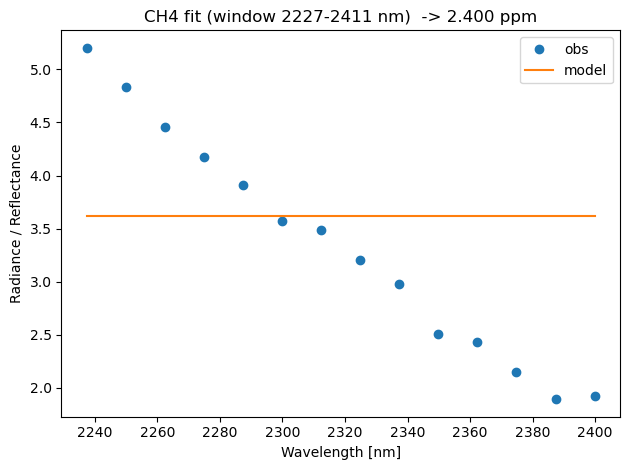

In [22]:

import numpy as np, pandas as pd
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

# 0) 観測（HISUI）を既存のdata_hisuiから取得
obs_wl_full = data_hisui.iloc[:, 0].to_numpy()   # [nm]
obs_I_full  = data_hisui.iloc[:, 1].to_numpy()   # radiance/reflectance

# 1) CH4ライブラリをロード（/mnt/data/CH4.csv）
lib = pd.read_csv(r"E:\refit\CH4.csv")
wl_lib = lib["wavelength"].to_numpy()
mr_cols = [c for c in lib.columns if c != "wavelength"]
mr_vals = np.array([float(c) for c in mr_cols])

# 2) 観測グリッドで窓を作る（まずは 2227–2411 nm）
start_nm, end_nm = 2227.0, 2411.0
obs_mask = (obs_wl_full >= start_nm) & (obs_wl_full <= end_nm)
# ポイントが少なすぎる場合は少し広げる
if obs_mask.sum() < 10:
    start_nm, end_nm = 2215.0, 2430.0
    obs_mask = (obs_wl_full >= start_nm) & (obs_wl_full <= end_nm)

# 選ばれた窓のインデックス（HISUIグリッド上）
idxs = np.where(obs_mask)[0]
HISUI_IDX_START = int(idxs.min())
HISUI_IDX_STOP  = int(idxs.max() + 1)  # stopは+1で排他的

# 3) ライブラリ→観測グリッドへ補間
def interp_to_obs(y_on_lib):
    return np.interp(obs_wl_full, wl_lib, y_on_lib, left=np.nan, right=np.nan)

# 4) 感度重み W = |dI/dppm| / I0 を観測グリッド上で作る（1.9ppm近傍）
target = 1.9
i = np.searchsorted(mr_vals, target)
i = np.clip(i, 1, len(mr_vals)-2)
I1_all = interp_to_obs(lib[mr_cols[i-1]].to_numpy())
I2_all = interp_to_obs(lib[mr_cols[i+1]].to_numpy())
I0_all = interp_to_obs(lib[mr_cols[0]].to_numpy())
dIdc_all = (I2_all - I1_all) / (mr_vals[i+1] - mr_vals[i-1])

# 窓で切る
y_obs_win = obs_I_full[idxs]
W_win = (np.abs(dIdc_all) / np.maximum(I0_all, 1e-12))[idxs]
finite = np.isfinite(y_obs_win) & np.isfinite(W_win)
y_obs_win = y_obs_win[finite]
W_win = W_win[finite]

# 5) 既存パイプラインでモデルを生成（c = 背景+Δm）
CH4_BG = 1.9  # 背景ppm

def run_model_vec(sigma, mu, a, b, dm, k):
    out = instrumental_function(data1, sigma, mu)
    out = extractdata(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_ch4(out, CH4_BG + dm)  # ★ 背景+Δm
    out = wavelength_adjustment_ch4(
        out,
        data1[0, PARAM_IDX_START:PARAM_IDX_STOP],
        data_hisui,
        hisui_start=HISUI_IDX_START,   # ★ デフォルトを使わず必ず明示
        hisui_stop=HISUI_IDX_STOP
    )
    return out  # 長さ = len(idxs)

# 6) 連続の初期値 b は既存の推定器があればそれを使う
try:
    b0 = estimate_param_ch4(data1, data_hisui)
except Exception:
    b0 = 1.0

# 7) 最小二乗（重み付き）
#    パラメタ: [sigma, mu, a, b, dm, k]
p0 = [6.5, 0.0, 1.0, b0, 0.0, 0.0]
lb = [0.5, -1.0, 0.2, 0.0, -0.5, -2.0]
ub = [20. , +1.0, 3.0, 5.0, +0.5, +2.0]

def residuals(p):
    sigma, mu, a, b, dm, k = p
    y_mod_full = run_model_vec(sigma, mu, a, b, dm, k)   # 長さ = len(idxs)
    y_mod = y_mod_full[finite]                            # 観測側のfiniteに合わせる
    return W_win * (y_mod - y_obs_win)

res = least_squares(residuals, p0, bounds=(lb, ub))
sigma_hat, mu_hat, a_hat, b_hat, dm_hat, k_hat = res.x
ch4_ppm = CH4_BG + dm_hat

print(f"CH4 estimate [ppm] = {ch4_ppm:.3f}")
print("params:",
      dict(sigma=sigma_hat, mu=mu_hat, a=a_hat, b=b_hat, dm=dm_hat, k=k_hat))
print("window points (obs):", idxs.size, " after finite filter:", finite.sum())

# 8) 可視化
y_mod_best = run_model_vec(sigma_hat, mu_hat, a_hat, b_hat, dm_hat, k_hat)[finite]
wl_win = obs_wl_full[idxs][finite]

plt.figure()
plt.plot(wl_win, y_obs_win, "o", label="obs")
plt.plot(wl_win, y_mod_best, "-", label="model")
plt.xlabel("Wavelength [nm]"); plt.ylabel("Radiance / Reflectance")
plt.title(f"CH4 fit (window {start_nm:.0f}-{end_nm:.0f} nm)  -> {ch4_ppm:.3f} ppm")
plt.legend(); plt.tight_layout(); plt.show()


In [9]:
import numpy as np, pandas as pd
from scipy.optimize import least_squares
from scipy.interpolate import interp1d

# --- 高感度窓を自動設定（2227–2411 nm） ---
w_all = data_hisui.iloc[:,0].to_numpy()
win_nm = (2227.0, 2411.0)  # 推奨窓
HISUI_IDX_START = int(np.searchsorted(w_all, win_nm[0], side="left"))
HISUI_IDX_STOP  = int(np.searchsorted(w_all, win_nm[1], side="right"))

# --- 感度重み（CH4.csvから） ---
df_ch4 = pd.read_csv("/mnt/data/CH4.csv")
wl_lib = df_ch4["wavelength"].to_numpy()
mr_cols = [c for c in df_ch4.columns if c != "wavelength"]
mr_vals = np.array([float(c) for c in mr_cols])
# 1.9 ppm 近傍の中心差分
i = np.searchsorted(mr_vals, 1.9); i = np.clip(i, 1, len(mr_vals)-2)
I1 = df_ch4[mr_cols[i-1]].to_numpy(); I2 = df_ch4[mr_cols[i+1]].to_numpy()
dIdc = (I2 - I1) / (mr_vals[i+1] - mr_vals[i-1])
I0  = df_ch4[mr_cols[0]].to_numpy()
sens_rel = np.abs(dIdc) / np.maximum(I0, 1e-12)
# HISUIの窓に合わせて補間→正規化
W = interp1d(wl_lib, sens_rel, bounds_error=False, fill_value=0.0)(
        w_all[HISUI_IDX_START:HISUI_IDX_STOP]
    )
W = W / np.median(W[W>0])  # 重みのスケールを安定化

# --- 観測（窓の切り出し） ---
y_obs = data_hisui.iloc[HISUI_IDX_START:HISUI_IDX_STOP, 1].to_numpy()

# --- 背景+Δm でのモデル ---
CH4_BG = 1.9  # 背景（固定でOK。後で推定に入れてもよい）

def func_ch4_delta(data, data_hisui, sigma, mu, a, b, dm, k):
    out = instrumental_function(data, sigma, mu)
    out = extractdata(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_ch4(out, CH4_BG + dm)  # ★ ここを「背景+Δ」に
    out = wavelength_adjustment_ch4(out, data[0, PARAM_IDX_START:PARAM_IDX_STOP], data_hisui)
    # 窓の部分だけ返す
    return out

def residuals_ch4_delta(param, data, data_hisui, W=None):
    sigma, mu, a, b, dm, k = param
    w_est = func_ch4_delta(data, data_hisui, sigma, mu, a, b, dm, k)
    r = y_obs - w_est
    return r if W is None else W * r

# --- 初期値と境界（b は既存の推定関数があるならそれを利用） ---
try:
    b0 = estimate_param_ch4(data, data_hisui)   # あなたのノートにある関数
except Exception:
    b0 = 1.0

p0 = [6.5, 0.0, 1.0, b0, 0.0, 0.0]       # [sigma, mu, a, b, Δm, k]
lb = [0.5, -1.0, 0.2, 0.0, -0.5, -2.0]
ub = [20. , +1.0, 3.0, 5.0, +0.5, +2.0]

res = least_squares(lambda p: residuals_ch4_delta(p, data, data_hisui, W), p0, bounds=(lb, ub))
sigma_hat, mu_hat, a_hat, b_hat, dm_hat, k_hat = res.x
ch4_ppm = CH4_BG + dm_hat
print(f"Estimated CH4 [ppm] = {ch4_ppm:.3f}")


NameError: name 'data_hisui' is not defined

Using image: E:\メタン\a\HSHL1G_N364E1407_20210810004959_20220830154054.tif
Optimized parameters: [ 5.49048938e+00  4.22969699e+00  1.46516909e+00 -5.74315299e-04
  8.24229047e+02  9.58934881e-01]
estimated c value: 824.2290473439236


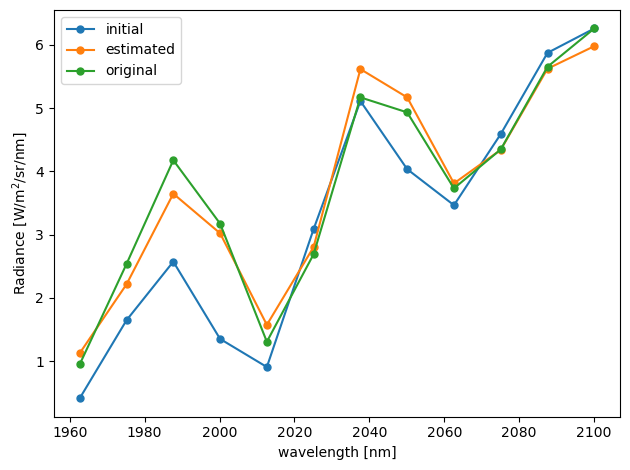

In [35]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from osgeo import gdal  # GDALで読み込み

# ===== 入力 =====
base_dir = r"E:\メタン\a"
x, y = 815, 580  # ← ここを自分で指定

# ===== 画像ファイルを探す =====
tif_files = sorted(glob.glob(os.path.join(base_dir, "*.tif")) + glob.glob(os.path.join(base_dir, "*.tiff")))
if not tif_files:
    raise FileNotFoundError("指定フォルダに .tif / .tiff が見つかりませんでした。")
img_path = tif_files[0]
print(f"Using image: {img_path}")

# ===== パラメータ・メタの読込 =====
param = read_bfile(img_path)  # 185x5想定（param[:,0]が中心波長[nm]）
radmultivnir, radmultiswir, radaddvnir, radaddswir = read_tfile(img_path)

# ===== 画像の読込（[bands, rows, cols] -> [rows, cols, bands]）=====
gdal.UseExceptions()
ds = gdal.Open(img_path, gdal.GA_ReadOnly)
if ds is None:
    raise RuntimeError(f"GDALで画像を開けませんでした: {img_path}")

arr = ds.ReadAsArray()  # shape: (bands, rows, cols)
if arr.ndim != 3:
    raise ValueError(f"想定外の配列次元: {arr.shape}")
img = np.moveaxis(arr, 0, -1).astype(np.float32)  # -> (rows, cols, bands)

# ===== 放射補正 =====
img_corr = apply_radiometric(img, radmultivnir, radmultiswir, radaddvnir, radaddswir)

# ===== 指定ピクセルのSWIRスペクトルを DataFrame に（列0=波長, 列1=値）=====
# ===== 指定ピクセルのSWIRスペクトルを DataFrame に（列0=波長, 列1=値）=====
SWIR = slice(0, 185)  # SWIRのバンド範囲（HISUI: 58..184）
wave = param[SWIR, 0].astype(float)                 # 波長 [nm]
rad  = img_corr[y, x, SWIR].astype(np.float64)      # 放射輝度（(y,x)注意）
data_hisui = pd.DataFrame({"wavelength_nm": wave, "radiance": rad})


# ===== 最適化の準備（data1 は事前に用意済みの想定）=====
assert 'data1' in globals(), "data1 が未定義です。モデル側データを先に用意してください。"

# 初期パラメータの設定
b = estimate_param_ch4(data1, data2)
a0 = np.array([6.5, 0.0, 0.0, b, 440, 0.0], dtype=float)

# 最適化の実行
res = least_squares(residuals_ch4, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)
print("estimated c value:", res.x[4])

# モデルの初期・推定カーブ（func_ch4 は data2 の一部レンジを返す想定）
w_int = func_ch4(data1, data2, *a0)      # 初期推定
w_est = func_ch4(data1, data2, *res.x)   # 最終推定

# ===== プロット範囲の決定 =====
# あなたの例のまま 106:121 を既定にしつつ、
# HISUI_IDX_START/STOP が定義されていればそれを優先して合わせます。
plot_i0 = globals().get('HISUI_IDX_START', 160)
plot_i1 = globals().get('HISUI_IDX_STOP', 170)

# func_ch4 の戻り長と data2 の範囲長を安全に合わせる
seg_len_model = len(w_int)
seg_len_data2 = plot_i1 - plot_i0
plot_len = min(seg_len_model, seg_len_data2)

x_axis = data2.iloc[plot_i0 : plot_i0 + plot_len, 0].to_numpy()
w_int_seg = np.asarray(w_int)[:plot_len]
w_est_seg = np.asarray(w_est)[:plot_len]
y_obs_seg = data2.iloc[plot_i0 : plot_i0 + plot_len, 1].to_numpy()

# ===== 図示 =====
plt.figure()
plt.plot(x_axis, w_int_seg, "-o", label="initial",  markersize=5)
plt.plot(x_axis, w_est_seg, "-o", label="estimated", markersize=5)
plt.plot(x_axis, y_obs_seg, "-o", label="original",  markersize=5)
plt.xlabel('wavelength [nm]')
plt.ylabel('Radiance [W/m$^2$/sr/nm]')
plt.legend()
plt.tight_layout()
plt.show()


In [34]:
def extract_co2(data): #範囲の選択
    return data[:, 1570:1722] #1950-2101nm

def estimated_by_co2(data, c): #二酸化炭素の量の推定, 5.0ppm刻みの水を線形補間
    co2 = np.arange(380, 380 + 20.0 * (data.shape[0]-1), 20.0)
    position = np.searchsorted(co2, c)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (co2[position] - c) / 20.0
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(84,97): #1950.175-2100.055nm
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_co2[position - 1] + (1 - r) * data_co2[position])
    return out

def func_co2(data, data_hisui, sigma, mu, a, b, c, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1570:1722], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c, k = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[84:97,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    max_ref = max(data_hisui.iloc[84:97,1]) #1950.175-2100.055nm
    rel_max_index = np.argmax(data_hisui.iloc[84:97,1])
    abs_max_index = data_hisui.iloc[84:97].index[rel_max_index]
    max_wave = data_hisui.iloc[abs_max_index, 0]
    out = instrumental_function(data, sigma=6.5, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=420)
    out = wavelength_adjustment_co2(out, data[0, 1570:1722], data_hisui)
    modtran = out[rel_max_index]
    b = max_ref / max_wave / modtran
    return b
    
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode='same') #畳み込み
    return out

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data


In [30]:
data2 = pd.read_csv("E:\新しいフォルダー\pixel_1000_1000.csv")
display(data2)
display(data1)

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\yudon\AppData\Local\Temp\ipykernel_29004\3700680556.py:1: SyntaxWarning: invalid escape sequence '\p'
  data2 = pd.read_csv("E:\新しいフォルダー\pixel_1000_1000.csv")


,Wavelength (nm),Radiance (W/m^2/μm/sr)
0,901.015,12.9120
1,913.505,12.3264
2,925.995,10.5888
3,938.485,4.4384
4,950.975,3.3600
...,...,...
122,2424.795,0.3104
123,2437.285,0.3040
124,2449.775,0.1824
125,2462.265,0.1472


array([[3.80000e+02, 3.81000e+02, 3.82000e+02, ..., 2.49800e+03,
        2.49900e+03, 2.50000e+03],
       [5.42295e+02, 6.37099e+02, 5.21107e+02, ..., 3.26572e-02,
        3.99838e-02, 3.63924e-02],
       [5.42304e+02, 6.37107e+02, 5.21112e+02, ..., 3.26570e-02,
        3.99833e-02, 3.63923e-02],
       ...,
       [5.42329e+02, 6.37137e+02, 5.21138e+02, ..., 3.26562e-02,
        3.99819e-02, 3.63915e-02],
       [5.42339e+02, 6.37150e+02, 5.21146e+02, ..., 3.26559e-02,
        3.99814e-02, 3.63913e-02],
       [5.42346e+02, 6.37158e+02, 5.21157e+02, ..., 3.26556e-02,
        3.99809e-02, 3.63911e-02]], shape=(8, 2121))

Optimized parameters: [ 7.59390177e+00  2.51310014e+00  3.65138652e-01 -9.75434862e-05
  4.46629335e+02  5.42706806e-02]
estimated water value: 446.62933474749263


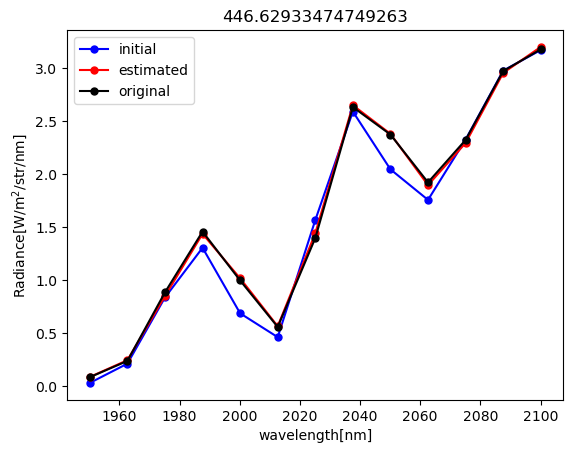

In [ ]:
# 初期パラメータの設定
b = estimate_param_co2(data1, data2)
a0 = np.array([6.5, 0, 0.0, b, 440, 0.0])
# 最適化の実行
res = least_squares(residuals_co2, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)

# 結果の図示
w_int = func_co2(data1, data2, *a0)
w_est = func_co2(data1, data2, *res.x)
print("estimated water value:", res.x[4])
plt.plot(data2.iloc[84:97,0], w_int, "-o", label="initial", markersize=5)
plt.plot(data2.iloc[84:97,0], w_est, "-o", label="estimated", markersize=5)
plt.plot(data2.iloc[84:97,0], data2.iloc[84:97,1], "-o", label="original", markersize=5)
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()

In [21]:
#装置関数と二酸化炭素の最小二乗法
def instrumental_function(data, sigma, mu): #装置関数
    column, row = data.shape #dataはMODTRAN6の結果
    x = data[0, :] #Wavelen
    out = np.zeros((column, row))
    out[0, :] = x
    ave = np.mean(x) #波長の平均値(中央値)
    gauss = np.exp(-(x - ave - mu)**2 / (2 * sigma**2)) / (sigma * np.sqrt(2 * np.pi)) #ガウス関数
    for i in range(1, column):
        y = data[i, :]
        out[i, :] = np.convolve(y, gauss, mode="same") #畳み込み
    return out

def extract_co2(data): #範囲の選択
    return data[:, 1570:1722]

def reflectance_correction(data, a, b, k): #反射率の考慮, 一次近似で良い
    column, row = data.shape
    x = data[0, :]
    for i in range(1, column):
        data[i, :] = (a + b * x) * data[i, :] + k
    return data

def estimated_by_co2(data, c): #二酸化炭素の量の推定, 5.0ppm刻みの水を線形補間
    co2 = np.arange(380, 380 + 20.0 * (data.shape[0]-1), 20.0)
    position = np.searchsorted(co2, c)
    out = []
    for i in range(data.shape[1]):
        if position + 1 < data.shape[0]:  # インデックスが範囲外にならないようにチェック
            r = (co2[position] - c) / 20.0
            interpolated_value = r * data[position, i] + (1 - r) * data[position + 1, i]
        else:
            interpolated_value = data[position, i]  # 最後のインデックスの場合、次の値がないためそのままの値を使用
        out.append(interpolated_value)
    return out

def wavelength_adjustment_co2(data_co2, array, data_hisui):  #波長を線形補間する
    out = []
    wave_width = 1.0 #ここで波長の刻み幅を変える
    for i in range(84,97): 
        position = np.searchsorted(array, data_hisui.iloc[i, 0]) #水の場所を求める
        r = (array[position] - data_hisui.iloc[i, 0]) / wave_width 
        out.append(r * data_co2[position - 1] + (1 - r) * data_co2[position])
    return out

def func_co2(data, data_hisui, sigma, mu, a, b, c, k):  #目的関数
    out = instrumental_function(data, sigma, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1570:1722], data_hisui)
    return out

def residuals_co2(param, data, data_hisui):  #残差
    sigma, mu, a, b, c, k = param
    w_est = func_co2(data, data_hisui, sigma, mu, a, b, c, k)
    return data_hisui.iloc[84:97,1] - w_est

def estimate_param_co2(data, data_hisui): #bの推定
    out = instrumental_function(data, sigma=6.0, mu=0.0)
    out = extract_co2(out)
    out = estimated_by_co2(out, c=420)
    out = wavelength_adjustment_co2(out, data[0, 1570:1722], data_hisui)
    out = np.array(out)
    highlight_points = [3,7,11] #1987.645, 2037.605, 2087.565nm
    x = data_hisui.iloc[84:97, 0].iloc[highlight_points]
    y = data_hisui.iloc[84:97, 1].iloc[highlight_points] / out[highlight_points]
    coefficients = np.polyfit(x, y, 1)
    return coefficients #[0]がb, [1]がaとなることに注意

sigma_co2 = 7.1

def func_co2_rev(data, data_hisui, mu, a, b, c, k):  #目的関数
    out = instrumental_function(data, sigma_co2, mu)
    out = extract_co2(out)
    out = reflectance_correction(out, a, b, k)
    out = estimated_by_co2(out, c)
    out = wavelength_adjustment_co2(out, data[0, 1570:1722], data_hisui) #2037-2088nm
    return out

def residuals_co2_rev(param, data, data_hisui):  #残差
    mu, a, b, c, k = param
    w_est = func_co2_rev(data, data_hisui, mu, a, b, c, k)
    return data_hisui.iloc[84:97,1] - w_est #2037.605-2087.565nm

from matplotlib.colors import ListedColormap
def heatmap_co2(data):
    out = data.copy()
    ave = np.average(data[7:19, 5:27, 0])
    upper_bound = ave * 1.15
    out[:,:] = np.where((data > upper_bound), np.nan, data)    
    out[:, 30:] = np.nan       
    out[:6, 15:] = np.nan     
    out[21:, 15:] = np.nan  
    ax = sns.heatmap(out, cmap="jet", vmin=380, vmax=500) 
    ax.set_xticks([])
    ax.set_yticks([])  
    plt.show()

Optimized parameters: [ 8.10969022e+00  2.20532948e+00  3.44101547e-02 -1.27681174e-05
  3.80000001e+02  7.54567272e-03]
estimated water value: 380.00000105395577


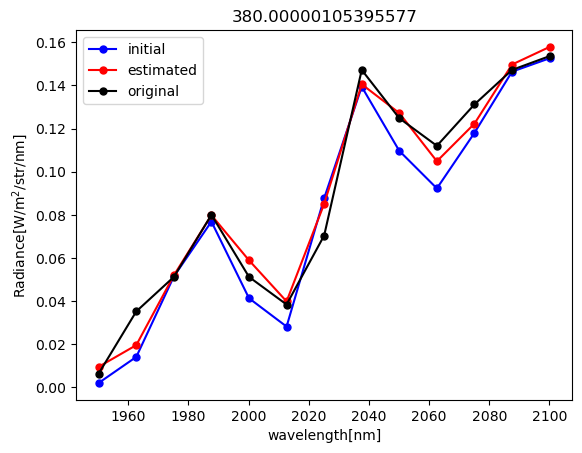

In [26]:
b, a = estimate_param_co2(data1, data2)
a0 = np.array([7.0, 0, a, b, 440, 0.0])
# 最適化の実行
res = least_squares(residuals_co2, a0, args=(data1, data2), method='lm')
print("Optimized parameters:", res.x)

# 結果の図示
w_int = func_co2(data1, data2, *a0)
w_est = func_co2(data1, data2, *res.x)
print("estimated water value:", res.x[4])
plt.title(res.x[4])
plt.plot(data2.iloc[84:97,0], w_int, "-o", color="blue", label="initial", markersize=5)
plt.plot(data2.iloc[84:97,0], w_est, "-o", color="red", label="estimated", markersize=5)
plt.plot(data2.iloc[84:97,0], data2.iloc[84:97,1], "-o", color="black", label="original", markersize=5)
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()

In [23]:
b, a = estimate_param_co2(data1, data2)
a0 =  np.array([6.0, 0.0, a, b, 420, 0.0])
res = least_squares(residuals_co2, a0, args=(data1, data2), method="lm")
out_co2[y,x,0] =  res.x[0] #sigma
out_co2[y,x,1] =  res.x[1] #mu
out_co2[y,x,2] =  res.x[4] #co2
out_co2[y,x,3] =  np.sum(residuals_co2(res.x, data1, data2))

NameError: name 'out_co2' is not defined

C:\Users\yudon\AppData\Local\Temp\ipykernel_29004\693452544.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


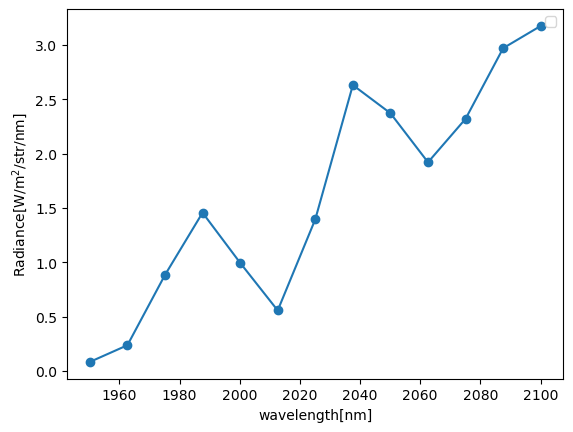

In [31]:
plt.plot(data2.iloc[84:97,0], data2.iloc[84:97,1], "-o") #1950.175-2100.055nm
plt.xlabel('wavelength[nm]')
plt.ylabel('Radiance[W/m$^2$/str/nm]')
plt.legend()
plt.show()